# (Simple) feature engineering
We can start with feature enginnering now. As we know, the model should predict whether two papers are duplicates, so we should load our training data first and then use it to attach our cleaned df 

In [1]:
# imports
import pandas as pd

In [2]:
train = pd.read_csv("data/train.csv")
train.head()

,Unnamed: 0,key1,key2,label,partition
0,0,conf/prib/AhmedF07,journals/jcc/PatraS09,False,7
1,1,conf/vlsid/ChenCC95,journals/tcad/LuoCWCCW08,True,4
2,2,conf/prozess/Sun88,conf/isnn/SunZLCS07,True,8
3,3,conf/pricai/BeaumontTSM04,conf/icip/SattarAS08,False,5
4,4,conf/dft/SemiaoRVSTT07,conf/iolts/Rodriguez-IragoAVSTT05,True,7


In [3]:
df = pd.read_csv("dblp_cleaned.csv")
df = df.drop(columns=["peditor", "paddress", "ppublisher", "pseries"])

Now we need to attach our dataframe for both papers by merging the DLBP table twice.

In [4]:
train_pairs = train.merge(
    df,
    left_on="key1",
    right_on="pkey",
    how="left"
)

train_pairs = train_pairs.merge(
    df,
    left_on="key2",
    right_on="pkey",
    how="left",
    suffixes=("_1", "_2")
)

print(train_pairs.columns)
print(train_pairs.shape)
train_pairs.head()

Index(['Unnamed: 0', 'key1', 'key2', 'label', 'partition_x', 'pauthor_1',
       'ptitle_1', 'pyear_1', 'pid_1', 'pkey_1', 'ptype_id_1', 'pjournal_id_1',
       'pbooktitle_id_1', 'pjournalfull_id_1', 'pbooktitlefull_id_1',
       'partition_y', 'pauthor_2', 'ptitle_2', 'pyear_2', 'pid_2', 'pkey_2',
       'ptype_id_2', 'pjournal_id_2', 'pbooktitle_id_2', 'pjournalfull_id_2',
       'pbooktitlefull_id_2', 'partition'],
      dtype='object')
(7972, 27)


,Unnamed: 0,key1,key2,label,partition_x,pauthor_1,ptitle_1,pyear_1,pid_1,pkey_1,...,ptitle_2,pyear_2,pid_2,pkey_2,ptype_id_2,pjournal_id_2,pbooktitle_id_2,pjournalfull_id_2,pbooktitlefull_id_2,partition
0,0,conf/prib/AhmedF07,journals/jcc/PatraS09,False,7,said hassan ahmed|tor flå,estimation of evolutionary average hydrophobic...,2007,793190,conf/prib/AhmedF07,...,artificial neural networks-based approach to d...,2009,2093393,journals/jcc/PatraS09,3,7,5,7,0,1
1,1,conf/vlsid/ChenCC95,journals/tcad/LuoCWCCW08,True,4,yung-yuan chen|ching-hwa cheng|jwu-e chen,an efficient switching network fault diagnosis...,1995,754984,conf/vlsid/ChenCC95,...,impact of capacitance correlation on yield enh...,2008,2235193,journals/tcad/LuoCWCCW08,3,220,5,220,5,1
2,2,conf/prozess/Sun88,conf/isnn/SunZLCS07,True,8,anwendung graphischer darstellungen im rahmen ...,z. sun,1988,648625,conf/prozess/Sun88,...,neuro-adaptive formation control of multi-mobi...,2007,519844,conf/isnn/SunZLCS07,1,0,436,0,436,3
3,3,conf/pricai/BeaumontTSM04,conf/icip/SattarAS08,False,5,matthew beaumont|john thornton|abdul sattar|mi...,solving over-constrained temporal reasoning pr...,2004,645750,conf/pricai/BeaumontTSM04,...,gagm-aam: a genetic optimization with gaussian...,2008,380526,conf/icip/SattarAS08,1,0,365,0,365,4
4,4,conf/dft/SemiaoRVSTT07,conf/iolts/Rodriguez-IragoAVSTT05,True,7,jorge semião|juan j. rodríguez-andina|fabian v...,improving the tolerance of pipeline based circ...,2007,180843,conf/dft/SemiaoRVSTT07,...,dynamic fault test and diagnosis in digital sy...,2005,478836,conf/iolts/Rodriguez-IragoAVSTT05,1,0,611,0,611,4


Now each row contains information on both paper 1, paper 2 and the label.
### Similarity features for feature engineering
I will start with some of the most intuitive and simpler features for the feature matrix. Based on the performance I get on a baseline we can then decide which features to work on and which other features to add or drop.

#### *Title similarity*
Probably the feature with the most potential, whether titles are similar is a great indicator of a duplicate entry. For now, for this we can use TF IDF and cosine similarity which is an industry standard and has been shown to perform well.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words="english")
tfidf = vectorizer.fit_transform(df["ptitle"].fillna(""))
key_to_index = {k: i for i, k in enumerate(df["pkey"])}

def title_similarity(row):
    i = key_to_index.get(row["key1"])
    j = key_to_index.get(row["key2"])
    
    if i is None or j is None:
        return 0
    
    return cosine_similarity(tfidf[i], tfidf[j])[0][0]

train_pairs["title_sim"] = train_pairs.apply(title_similarity, axis=1)

#### *Author similarity*

Another feature we can use is whether the authors are the same. 

In [6]:
def author_jaccard(a1, a2):
    if pd.isna(a1) or pd.isna(a2):
        return 0
    
    s1 = set(a1.split("|"))
    s2 = set(a2.split("|"))
    
    return len(s1 & s2) / len(s1 | s2)

train_pairs["author_jaccard"] = train_pairs.apply(
    lambda x: author_jaccard(x["pauthor_1"], x["pauthor_2"]),
    axis=1
)

#### *Publication Year Difference*

We can also compute the difference between the publication years of the 2 papers as another feature, based on the fact that papers that share the same year (or are closer in years) have a higher chance of being duplicates

In [7]:
train_pairs["year_diff"] = abs(train_pairs["pyear_1"] - train_pairs["pyear_2"])

#### *Journal/Book Match*

Another feature we can use is whether the venues match

In [8]:
train_pairs["venue_1"] = train_pairs["key1"].str.split("/").str[1]
train_pairs["venue_2"] = train_pairs["key2"].str.split("/").str[1]

train_pairs["venue_match"] = (
    train_pairs["venue_1"] == train_pairs["venue_2"]
).astype(int)

known_prefixes = {"conf", "journals"}
prefix_1 = train_pairs["key1"].str.split("/").str[0]
prefix_2 = train_pairs["key2"].str.split("/").str[0]

train_pairs["venue_known"] = (
    prefix_1.isin(known_prefixes) & prefix_2.isin(known_prefixes)
).astype(int)

## TODO
- whether the acronyms match (create acronym from full journal or book title?)

We can also check whether the publication is of the same type

In [9]:
train_pairs["same_ptype"] = (
    train_pairs["ptype_id_1"] == train_pairs["ptype_id_2"]
).astype(int)

### Building the feature matrix

Our final feature set is then:

In [10]:
features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "venue_match",
    "venue_known",
    "same_ptype"
]

Now we can build the feature matrix with our features:

In [11]:
X = train_pairs[features]
y = train_pairs["label"]

Let's check that the binary classes are balanced and there are no nan values:

In [12]:
X.head()
y.value_counts() 

label
False    4027
True     3945
Name: count, dtype: int64

In [13]:
X.isna().sum()

title_sim         0
author_jaccard    0
year_diff         0
venue_match       0
venue_known       0
same_ptype        0
dtype: int64

### Train/validation split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2, # 80/20 split since it is standard
    stratify=y,
    random_state=42
)

# Baseline (Logistic Regression)

To start we can train a simple logistic regression to keep as a baseline. 

In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


We can evaluate the model with both accuracy and AUC.

In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

preds = model.predict_proba(X_val)[:,1]

print("ROC:", roc_auc_score(y_val, preds))
print("Accuracy:", accuracy_score(y_val, preds.round()))
print("Precision:", precision_score(y_val, preds.round()))
print("Recall:", recall_score(y_val, preds.round()))
print("F1 Score:", f1_score(y_val, preds.round()))

ROC: 0.8830649092515891
Accuracy: 0.8501567398119122
Precision: 0.9910714285714286
Recall: 0.7034220532319392
F1 Score: 0.8228317272053373


This performance is already quite good for a baseline and our first try at feature engineering.

Lets check with features from our matrix are most relevant when identifying duplicates:

In [17]:
pd.Series(
    model.coef_[0],
    index=features
).sort_values(ascending=False)

author_jaccard    16.488125
title_sim          6.548670
venue_match        2.627715
same_ptype         0.145401
year_diff          0.023360
venue_known       -0.281681
dtype: float64

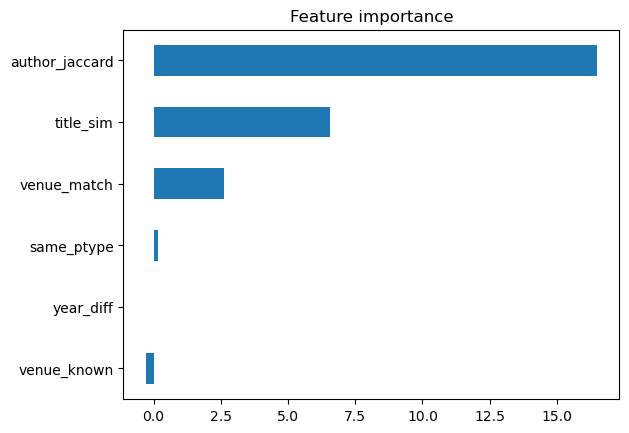

In [18]:
import matplotlib.pyplot as plt

pd.Series(
    model.coef_[0],
    index=features
).sort_values().plot(kind="barh")

plt.title("Feature importance")
plt.show()

My conclusion so far is this: this is not a bad result, but we can probably achieve higher performance if we work on the features more. The fact that authors similarity is more telling than title similarity is interesting. This could be because author names are much more unique than title words. We can try implementing a more robust way to check similarity, instead of TF-IDF and see if that improves performance. Year difference is pretty straightforward, as well as the others. Let's see what changes we can make to our features and up the performance of our baseline.

### 1st attempt at improving feature engineering 

Firstly, we can try and match, instead of the whole author list, the first author in the list. This could be a more unique identifier of same author lists (therefore a duplicate).

In [19]:
def first_author(a):
    if pd.isna(a):
        return ""
    return a.split("|")[0]

train_pairs["first_author_match"] = (
    train_pairs["pauthor_1"].apply(first_author) ==
    train_pairs["pauthor_2"].apply(first_author)
).astype(int)

We can also calculate the difference in lenght across titles, which might be a good combination with title similarity.

In [20]:
train_pairs["title_len_diff"] = (
    train_pairs["ptitle_1"].str.len() -
    train_pairs["ptitle_2"].str.len()
).abs()

We can also try and match words that titles share

In [21]:
def shared_words(t1, t2):
    if pd.isna(t1) or pd.isna(t2):
        return 0

    s1 = set(t1.lower().split())
    s2 = set(t2.lower().split())

    return len(s1 & s2)

train_pairs["shared_title_words"] = train_pairs.apply(
    lambda x: shared_words(x["ptitle_1"], x["ptitle_2"]),
    axis=1
)

Instead of calculating year difference, we can match the year to see if it is the same.

In [22]:
train_pairs["same_year"] = (
    train_pairs["pyear_1"] == train_pairs["pyear_2"]
).astype(int)

Lastly we can calculate how many authors in total each publication contains, and calculate the difference between the two papers.

In [23]:
train_pairs["author_count_1"] = train_pairs["pauthor_1"].fillna("").str.count("\|") + 1
train_pairs["author_count_2"] = train_pairs["pauthor_2"].fillna("").str.count("\|") + 1

train_pairs["author_count_diff"] = (
    train_pairs["author_count_1"] - train_pairs["author_count_2"]
).abs()

We now build the hopefully improved feature matrix again

In [24]:
features_new = [
    "title_sim",
    "first_author_match",
    "shared_title_words",
    "title_len_diff",
    "same_year",
    "author_count_diff",
    "venue_match",
    "venue_known",
    "same_ptype"
]

In [25]:
train_pairs.columns

Index(['Unnamed: 0', 'key1', 'key2', 'label', 'partition_x', 'pauthor_1',
       'ptitle_1', 'pyear_1', 'pid_1', 'pkey_1', 'ptype_id_1', 'pjournal_id_1',
       'pbooktitle_id_1', 'pjournalfull_id_1', 'pbooktitlefull_id_1',
       'partition_y', 'pauthor_2', 'ptitle_2', 'pyear_2', 'pid_2', 'pkey_2',
       'ptype_id_2', 'pjournal_id_2', 'pbooktitle_id_2', 'pjournalfull_id_2',
       'pbooktitlefull_id_2', 'partition', 'title_sim', 'author_jaccard',
       'year_diff', 'venue_1', 'venue_2', 'venue_match', 'venue_known',
       'same_ptype', 'first_author_match', 'title_len_diff',
       'shared_title_words', 'same_year', 'author_count_1', 'author_count_2',
       'author_count_diff'],
      dtype='object')

Then we build the training matrix again

In [26]:
train_pairs.drop(columns=["title_jaccard"], inplace=True, errors="ignore")

In [27]:
X = train_pairs.loc[:, features_new].copy()
y = train_pairs["label"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
preds = model.predict_proba(X_val)[:,1]
print("ROC:", roc_auc_score(y_val, preds))
print("Accuracy:", accuracy_score(y_val, preds.round()))
print("Precision:", precision_score(y_val, preds.round()))
print("Recall:", recall_score(y_val, preds.round()))
print("F1 Score:", f1_score(y_val, preds.round()))

ROC: 0.7461426814732346
Accuracy: 0.7184952978056426
Precision: 0.912621359223301
Recall: 0.47655259822560203
F1 Score: 0.6261448792672772


In [31]:
pd.Series(
    model.coef_[0],
    index=features_new
).sort_values(ascending=False)

title_sim             8.001468
first_author_match    4.515342
venue_match           2.929460
same_ptype            0.226350
shared_title_words    0.140299
title_len_diff       -0.000926
same_year            -0.033123
author_count_diff    -0.074411
venue_known          -0.165343
dtype: float64

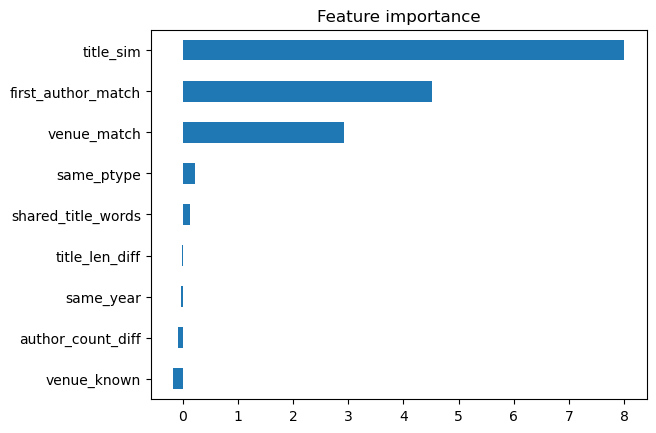

In [32]:
import matplotlib.pyplot as plt

pd.Series(
    model.coef_[0],
    index=features_new
).sort_values().plot(kind="barh")

plt.title("Feature importance")
plt.show()

Well, clearly that did not help. Our previous implementaitons of these features worked much better. The biggest takeaway is that we need to match the entire author list isntead of only the first author to improve performance (which makes sense). Title similarity is now the strongest feature to identify duplicate but this is because of the author implementation. The bottom 4 features, we can drop since they do not add any value to the model at all. 

### 2nd attempt at improving feature engineering

One last try with the title computation, we can try and see if using Jaccard helps along with the original features we had from our first implementation:

In [33]:
def title_jaccard(t1,t2):
    s1=set(t1.split())
    s2=set(t2.split())
    return len(s1&s2)/max(len(s1|s2),1)

train_pairs["title_jaccard"]=train_pairs.apply(
    lambda x:title_jaccard(x["ptitle_1"],x["ptitle_2"]),
    axis=1
)

In [34]:
features_new_new= [
    "title_jaccard",
    "author_jaccard",
    "year_diff",
    "venue_match",
    "venue_known",
    "same_ptype"
]

In [35]:
X = train_pairs.loc[:, features_new_new].copy()
y = train_pairs["label"]
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [36]:
print(len(features_new_new))
print(X.shape)

6
(7972, 6)


In [37]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
preds = model.predict_proba(X_val)[:,1]
print("ROC:", roc_auc_score(y_val, preds))
print("Accuracy:", accuracy_score(y_val, preds.round()))
print("Precision:", precision_score(y_val, preds.round()))
print("Recall:", recall_score(y_val, preds.round()))
print("F1 Score:", f1_score(y_val, preds.round()))

ROC: 0.8658626524136153
Accuracy: 0.8369905956112853
Precision: 0.994392523364486
Recall: 0.6742712294043093
F1 Score: 0.8036253776435045


In [39]:
pd.Series(
    model.coef_[0],
    index=features_new_new
).sort_values(ascending=False)

author_jaccard    16.708981
title_jaccard      3.829968
venue_match        2.670460
same_ptype         0.151460
year_diff          0.020128
venue_known       -0.304701
dtype: float64

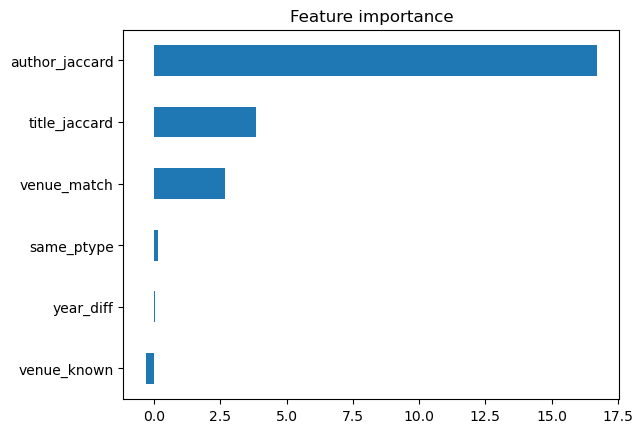

In [40]:
import matplotlib.pyplot as plt

pd.Series(
    model.coef_[0],
    index=features_new_new
).sort_values().plot(kind="barh")

plt.title("Feature importance")
plt.show()

Conclusion: calculating title similarity with jaccard actually decreases performance by a bit. We should then keep out title_sim variable for this since our original implementation actually gave us the highest performance of all. So far, the best feature list we have found is:
features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "same_journal",
    "same_booktitle",
    "same_ptype"
]


In general, auhtor lists are the most important when checking for duplicates.Then titles, then venue info and then year. The additional features really did not add much, likely because they correlated with similar versions of themselves that we already had implemented so the improvements were not significant. At this point we should try to use an optimizer to find us the best combination of features out of all the ones we just created.

### Search for best features with L1 regularization

We can try using L1 regularization to find the best features combinations with all the features we computed so far.

In [41]:
from sklearn.linear_model import LogisticRegression

all_features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "venue_match",
    "venue_known",
    "same_ptype",
    "first_author_match",
    "shared_title_words",
    "title_len_diff",
    "same_year",
    "author_count_diff",
    "title_jaccard"
]

X = train_pairs[all_features].fillna(0)

model_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

model_l1.fit(X, y)
model.fit(train_pairs[all_features].fillna(0), y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [42]:
coef = pd.Series(model_l1.coef_[0], index=all_features)
coef.sort_values(ascending=False)

author_jaccard        46.233350
title_sim             10.730833
venue_match            2.873172
same_ptype             0.139257
year_diff              0.029135
shared_title_words     0.019061
first_author_match     0.000000
title_jaccard          0.000000
title_len_diff        -0.001326
author_count_diff     -0.059228
same_year             -0.177334
venue_known           -0.382902
dtype: float64

In [43]:
selected_features = coef[coef != 0].index.tolist()
selected_features

['title_sim',
 'author_jaccard',
 'year_diff',
 'venue_match',
 'venue_known',
 'same_ptype',
 'shared_title_words',
 'title_len_diff',
 'same_year',
 'author_count_diff']

<Axes: >

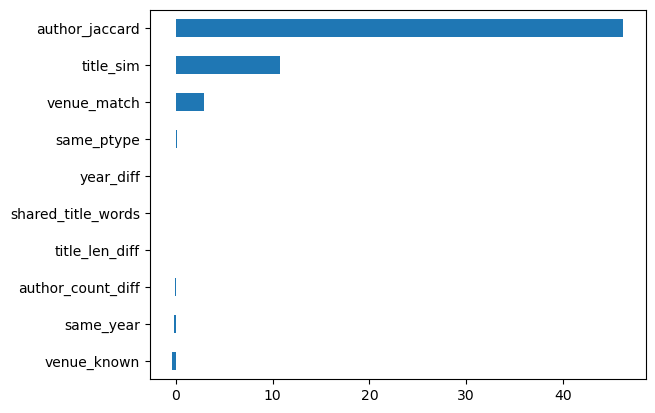

In [44]:
coef[coef != 0].sort_values().plot(kind="barh")

In [45]:
y_pred = model_l1.predict(X)
y_prob = model_l1.predict_proba(X)[:, 1]

In [46]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y, y_pred))
print("ROC AUC:", roc_auc_score(y, y_prob))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1 Score:", f1_score(y, y_pred))

Accuracy: 0.8302809834420471
ROC AUC: 0.8666152079294924
Precision: 0.9688856729377714
Recall: 0.6788339670468948
F1 Score: 0.7983306006856461


As we can see, L1 regularization does not improve the feature list, if anything it achieved slighly lower performance than our original implementaiton (which had ROC AUC ≈ 0.885, Accuracy ≈ 0.846). However it did confirm that author_jaccard and title_sim are the most important features.

# Baseline 2 (decision tree classifier)

As another baseline it is good to have a tree-based method since most likely our main model will be tree-based as well. I will train a simple decision tree with the original feature list since it has proven most successful thus far.

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "venue_match",
    "venue_known",
    "same_ptype"
]

X = train_pairs[features].fillna(0)
y = train_pairs["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
pred = dt.predict(X_val)
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

       False       0.79      0.97      0.87       806
        True       0.96      0.74      0.83       789

    accuracy                           0.85      1595
   macro avg       0.87      0.85      0.85      1595
weighted avg       0.87      0.85      0.85      1595



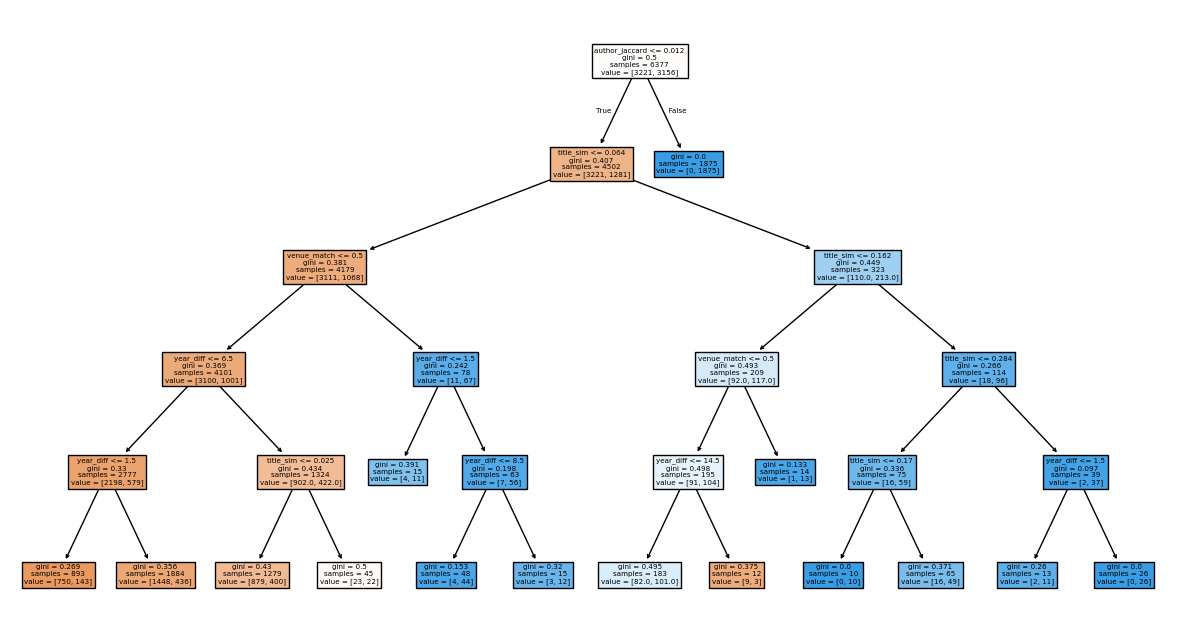

In [49]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,8))
plot_tree(dt, feature_names=features, filled=True)
plt.show()

In [50]:
train_pairs.to_csv("train_pairs_features.csv", index=False)

### Summary

Highest performance so far achieved with the original `features` implementation:

ROC: 0.8851893435482298

Accuracy: 0.8463949843260188

Precision: 0.9927536231884058

Recall: 0.6945500633713562

F1 Score: 0.8173005219985086

with Logistic Regression

Most important features currently:

author_jaccard

title_sim

same_book_title

same_ptype

same_journal
